# Impact of Image Resolution and Augmentation on Chest X-Ray Classification

This notebook investigates how different preprocessing strategies affect CNN performance on the Chest X-Ray Pneumonia dataset.

We evaluate the same CNN architecture under four experimental setups:

1. **224×224 grayscale images (baseline)**
2. **512×512 grayscale images**
3. **224×224 with random augmentations** (contrast jitter, rotation, horizontal flip)
4. **224×224 with augmentations + normalization to [-1, 1]**

Our goal is to measure the effect of input resolution and augmentation techniques on the classification accuracy and generalization ability of the model.


We expect:

- Higher resolution (512×512) may capture finer details but increase overfitting and CPU cost.
- Augmentation should improve generalization by simulating variability.
- Normalization helps the optimizer converge faster and can improve overall performance.

## Dependency installation 

In [1]:
!pip install pandas matplotlib seaborn scikit-learn pyarrow


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import and reading datas

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np

# Load parquet files
metrics_224 = pd.read_parquet("../output/ChestXRayCNN_ChestXRay_224_e10_metrics.parquet")
preds_224 = pd.read_parquet("../output/ChestXRayCNN_ChestXRay_224_e10_preds.parquet")

metrics_512 = pd.read_parquet("../output/ChestXRayCNN_ChestXRay_512_e10_metrics.parquet")
preds_512 = pd.read_parquet("../output/ChestXRayCNN_ChestXRay_512_e10_preds.parquet")

metrics_224_mods = pd.read_parquet("../output/ChestXRayCNN_ChestXRay_224_e10_rmods_metrics.parquet")
preds_224_mods = pd.read_parquet("../output/ChestXRayCNN_ChestXRay_224_e10_rmods_preds.parquet")

metrics_224_norm = pd.read_parquet("../output/ChestXRayCNN_ChestXRay_224_e10_rmods_norm_metrics.parquet")
preds_224_norm = pd.read_parquet("../output/ChestXRayCNN_ChestXRay_224_e10_rmods_norm_preds.parquet")

# Quick look
metrics_224.head()

,epoch,train_loss,test_loss,accuracy
0,1,0.0,0.681969,0.625000
1,2,0.0,0.690703,0.625000
2,3,0.0,0.637199,0.625000
3,4,0.0,0.713176,0.628205
4,5,0.0,0.346175,0.841346


In [7]:
preds_224.head()

,epoch,sample_index,predicted_label,true_label,confidence,embed_0,embed_1,embed_2,embed_3,embed_4,...,embed_246,embed_247,embed_248,embed_249,embed_250,embed_251,embed_252,embed_253,embed_254,embed_255
0,1,0,1,0,0.717825,0.234141,0.168864,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.042243,0.0,0.182981,0.0,0.0,0.0
1,1,1,1,0,0.722180,0.229320,0.170684,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.039403,0.0,0.188874,0.0,0.0,0.0
2,1,2,1,0,0.721192,0.236529,0.172354,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.034495,0.0,0.184621,0.0,0.0,0.0
3,1,3,1,0,0.723901,0.235018,0.181053,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.040935,0.0,0.189914,0.0,0.0,0.0
4,1,4,1,0,0.721292,0.236491,0.170921,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.042373,0.0,0.187324,0.0,0.0,0.0


## Data Repartition

In [21]:
import os

def count_images_by_class(base_path):
    split_counts = {}
    for split in ['train', 'test']:
        split_path = os.path.join(base_path, split)
        class_counts = {}
        if not os.path.isdir(split_path):
            print(f"Warning: {split_path} does not exist.")
            continue
        for cls in os.listdir(split_path):
            class_path = os.path.join(split_path, cls)
            if os.path.isdir(class_path):
                n_images = sum(
                    1 for f in os.listdir(class_path)
                    if os.path.isfile(os.path.join(class_path, f))
                )
                class_counts[cls] = n_images
        split_counts[split] = class_counts
    return split_counts

# Example usage
base_dataset_path = "../datas/chest_Xray/"
counts = count_images_by_class(base_dataset_path)

# Display counts nicely
for split, classes in counts.items():
    print(f"\n📁 {split.upper()}:")
    for cls, count in classes.items():
        print(f"  - {cls}: {count} images")


📁 TRAIN:
  - NORMAL: 1341 images
  - PNEUMONIA: 3875 images

📁 TEST:
  - NORMAL: 234 images
  - PNEUMONIA: 390 images


## Accuracy over epoch

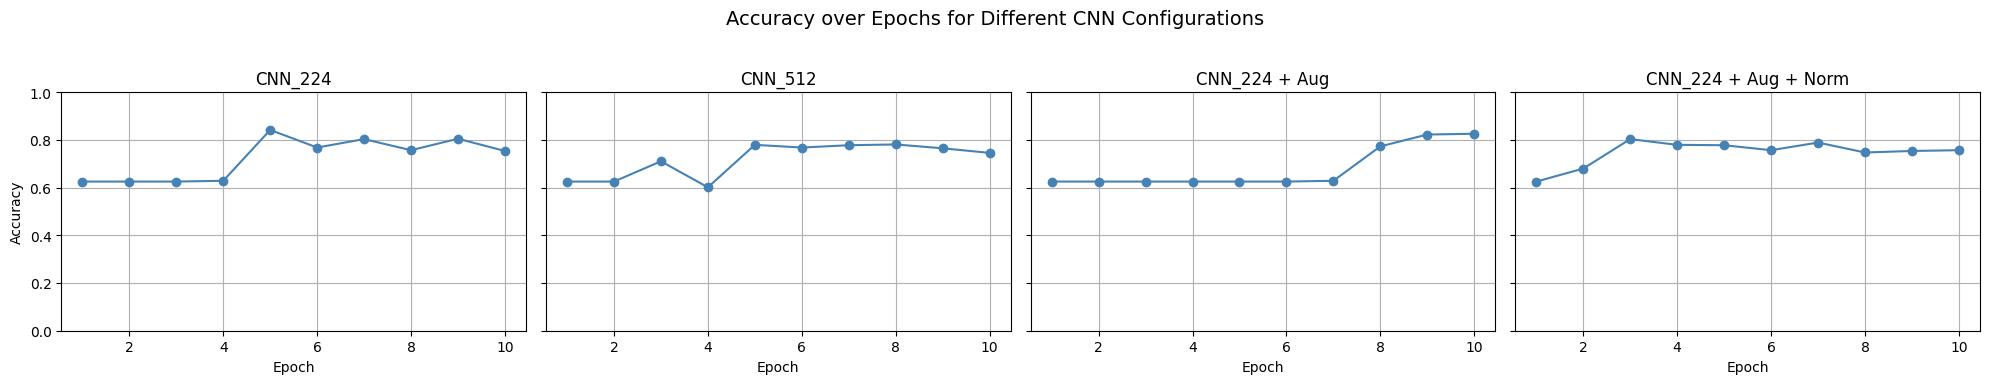

In [32]:

# Titles and metrics data
metric_sets = [
    ("CNN_224", metrics_224),
    ("CNN_512", metrics_512),
    ("CNN_224 + Aug", metrics_224_mods),
    ("CNN_224 + Aug + Norm", metrics_224_norm)
]

# Create subplots
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
a
# Plot accuracy vs epoch
for ax, (title, df) in zip(axes, metric_sets):
    ax.plot(df["epoch"], df["accuracy"], marker='o', label="Accuracy", color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy" if ax == axes[0] else "")
    ax.set_ylim(0, 1)
    ax.grid(True)

plt.suptitle("Accuracy over Epochs for Different CNN Configurations", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Confusion Matrixs

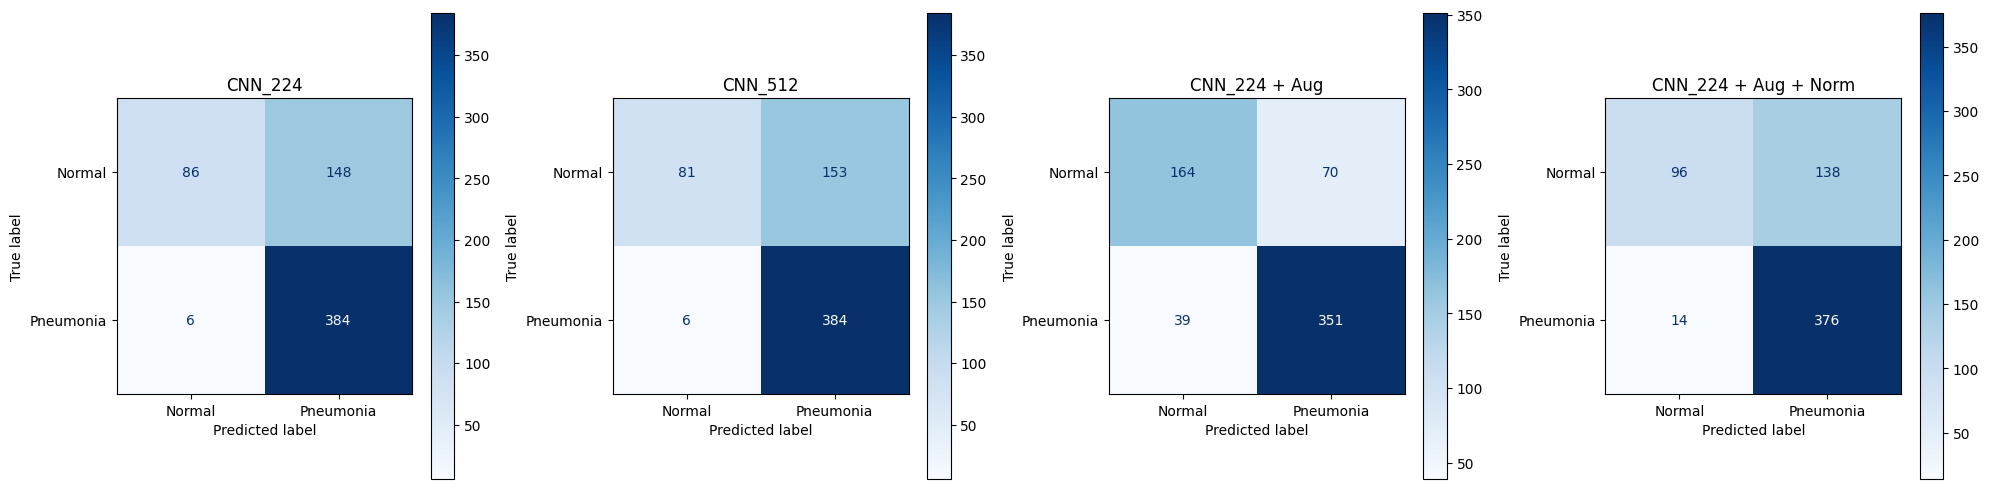

In [31]:
# Filter predictions at epoch 10
preds_224_e10 = preds_224[preds_224["epoch"] == 10]
preds_512_e10 = preds_512[preds_512["epoch"] == 10]
preds_224_mods_e10 = preds_224_mods[preds_224_mods["epoch"] == 10]
preds_224_norm_e10 = preds_224_norm[preds_224_norm["epoch"] == 10]

# Titles and datasets
configs = [
    ("CNN_224", preds_224_e10),
    ("CNN_512", preds_512_e10),
    ("CNN_224 + Aug", preds_224_mods_e10),
    ("CNN_224 + Aug + Norm", preds_224_norm_e10)
]

# Create subplots
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Plot confusion matrices
for ax, (title, df) in zip(axes, configs):
    cm = confusion_matrix(df["true_label"], df["predicted_label"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Pneumonia"])
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(title)

plt.tight_layout()
plt.show()

C:\Users\bervo\AppData\Local\Temp\ipykernel_22644\3583298797.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  class_acc = df.groupby("true_label", as_index=False).apply(
C:\Users\bervo\AppData\Local\Temp\ipykernel_22644\3583298797.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  class_acc = df.groupby("true_label", as_index=False).apply(
C:\Users\bervo\AppData\Local\Temp\ipykernel_22644\3583298797.py:13: Futu

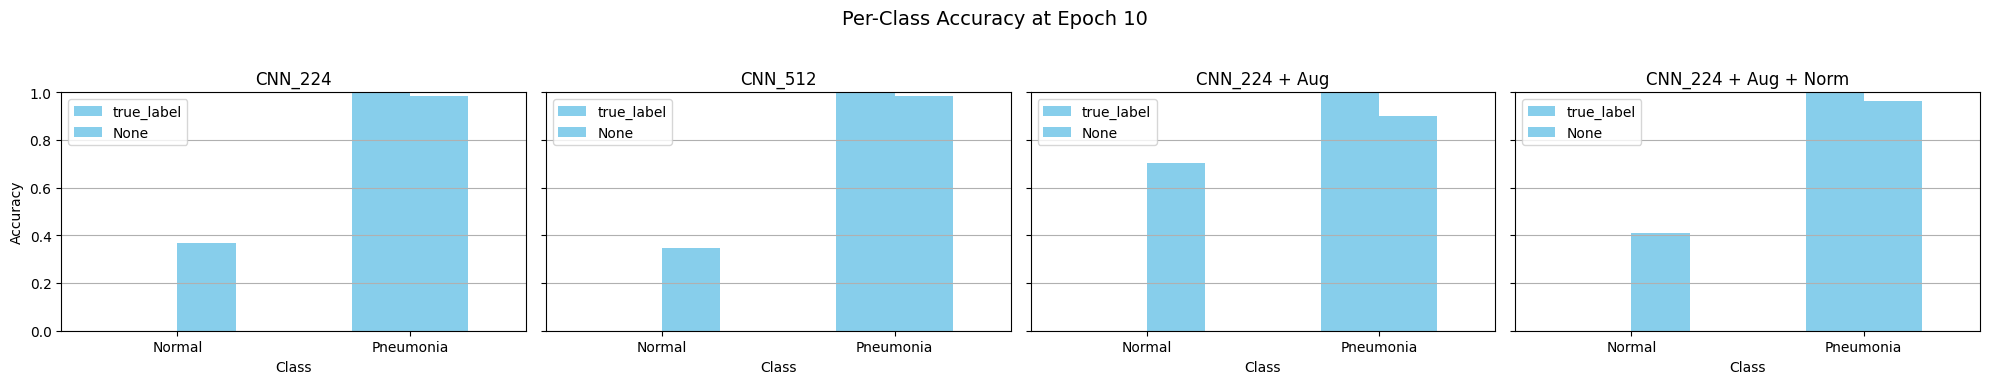

In [42]:
pred_sets = [
    ("CNN_224", preds_224[preds_224["epoch"] == 10]),
    ("CNN_512", preds_512[preds_512["epoch"] == 10]),
    ("CNN_224 + Aug", preds_224_mods[preds_224_mods["epoch"] == 10]),
    ("CNN_224 + Aug + Norm", preds_224_norm[preds_224_norm["epoch"] == 10])
]

# Create subplots
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)

# Plot per-class accuracy bars
for ax, (title, df) in zip(axes, pred_sets):
    class_acc = df.groupby("true_label", group_keys=False).apply(
        lambda d: (d["true_label"] == d["predicted_label"]).mean()
    )
    class_acc.plot(kind="bar", ax=ax, title=title, color="skyblue")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Class")
    if ax == axes[0]:
        ax.set_ylabel("Accuracy")
    ax.grid(True, axis="y")
    ax.set_xticklabels(["Normal", "Pneumonia"], rotation=0)

plt.suptitle("Per-Class Accuracy at Epoch 10", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


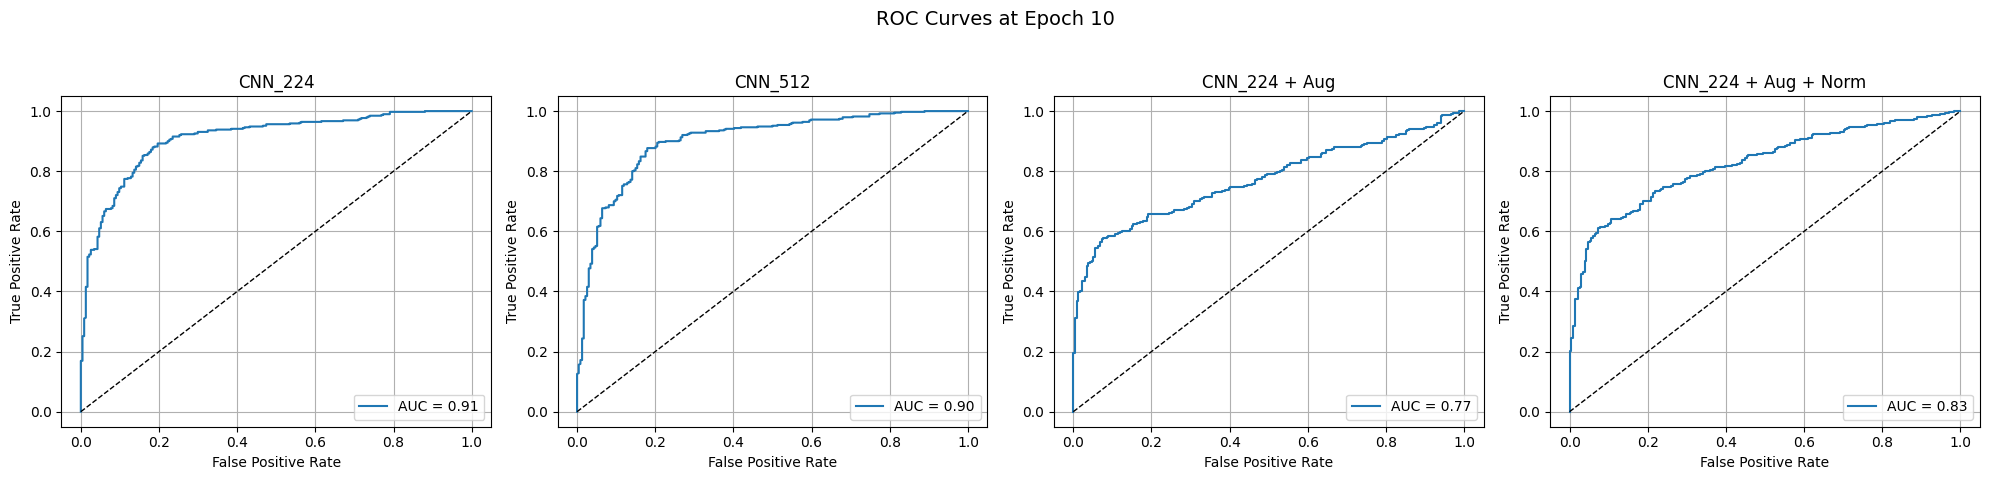

In [45]:
# Filter predictions at epoch 10
preds_224_e10 = preds_224[preds_224["epoch"] == 10]
preds_512_e10 = preds_512[preds_512["epoch"] == 10]
preds_224_mods_e10 = preds_224_mods[preds_224_mods["epoch"] == 10]
preds_224_norm_e10 = preds_224_norm[preds_224_norm["epoch"] == 10]

# Titles and datasets
configs = [
    ("CNN_224", preds_224_e10),
    ("CNN_512", preds_512_e10),
    ("CNN_224 + Aug", preds_224_mods_e10),
    ("CNN_224 + Aug + Norm", preds_224_norm_e10)
]

# Create subplots
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Plot ROC curves
for ax, (title, df) in zip(axes, configs):
    y_true = df["true_label"]
    y_score = df["confidence"]  # make sure this column exists
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(title)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(True)

plt.suptitle("ROC Curves at Epoch 10", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()